## Property 4: Fuzzy Boundaries

In [1]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np
from collections import defaultdict
from matplotlib.ticker import MaxNLocator

In [2]:
# Import Data

attributes_df  = pd.read_csv('01_catmemexp_attributestask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df['output_list_processed_nonoise'] = attributes_df['output_list_processed_nonoise'].apply(ast.literal_eval)

items_df = pd.read_csv('01_catmemexp_itemstask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

unique_attributes_df  = pd.read_csv('famres_scores_df.csv')
unique_attributes_df.head()

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency
0,Qwen2.5-7B-Instruct,Furniture,armchair,"['upholstered', 'seating', 'portable', 'armres...","[np.int64(4), np.int64(5), np.int64(3), np.int...",44,12.727720,22
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"['static', 'storage', 'sturdy', 'organized', '...","[np.int64(1), np.int64(6), np.int64(6), np.int...",52,12.727720,29
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"['multi-level', 'bed', 'space-saving', 'twin',...","[np.int64(3), np.int64(1), np.int64(1), np.int...",28,5.455321,9
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"['practical', 'cabinetry', 'storage', 'fixed',...","[np.int64(3), np.int64(2), np.int64(6), np.int...",46,11.341425,8
4,Qwen2.5-7B-Instruct,Furniture,chair,"['stable', 'four-legged', 'upholstered', 'seat...","[np.int64(3), np.int64(1), np.int64(4), np.int...",54,15.079095,30


In [ ]:
# Categories to drop
categories_to_drop = ["Toy", "Carpenter's Tool", "Bird", "Sport"]
items_df = items_df[~items_df['category'].isin(categories_to_drop)]

In [ ]:
model_dataframes = {}

unique_models = items_df['model'].unique()

for model in unique_models:
    
    model_df = items_df[items_df['model'] == model]
    
    grouped = model_df.groupby('category')['output_list_processed_nonoise'].agg(lambda x: set(sum(x, [])))

    common_counts = pd.DataFrame(index=grouped.index, columns=grouped.index)

    for cat1 in grouped.index:
        for cat2 in grouped.index:
            if cat1 != cat2:
                common_count = len(grouped[cat1].intersection(grouped[cat2]))
                common_counts.loc[cat1, cat2] = common_count
            else:
                common_counts.loc[cat1, cat2] = len(grouped[cat1])

    model_dataframes[model] = common_counts

for model, counts in model_dataframes.items():
    print(f"\n{model}")
    print(counts)


Qwen2.5-7B-Instruct
category         Carpenter's tool Clothing Fruit Furniture Vegetable Vehicle  \
category                                                                       
Carpenter's tool               16        0     0         0         0       0   
Clothing                        0       30     0         0         0       0   
Fruit                           0        0    16         0         0       0   
Furniture                       0        0     0        34         0       0   
Vegetable                       0        0     0         0        18       0   
Vehicle                         0        0     0         0         0      19   
Weapon                          1        0     0         0         0       0   

category         Weapon  
category                 
Carpenter's tool      1  
Clothing              0  
Fruit                 0  
Furniture             0  
Vegetable             0  
Vehicle               0  
Weapon               29  

Qwen2.5-14B-Instruct
ca

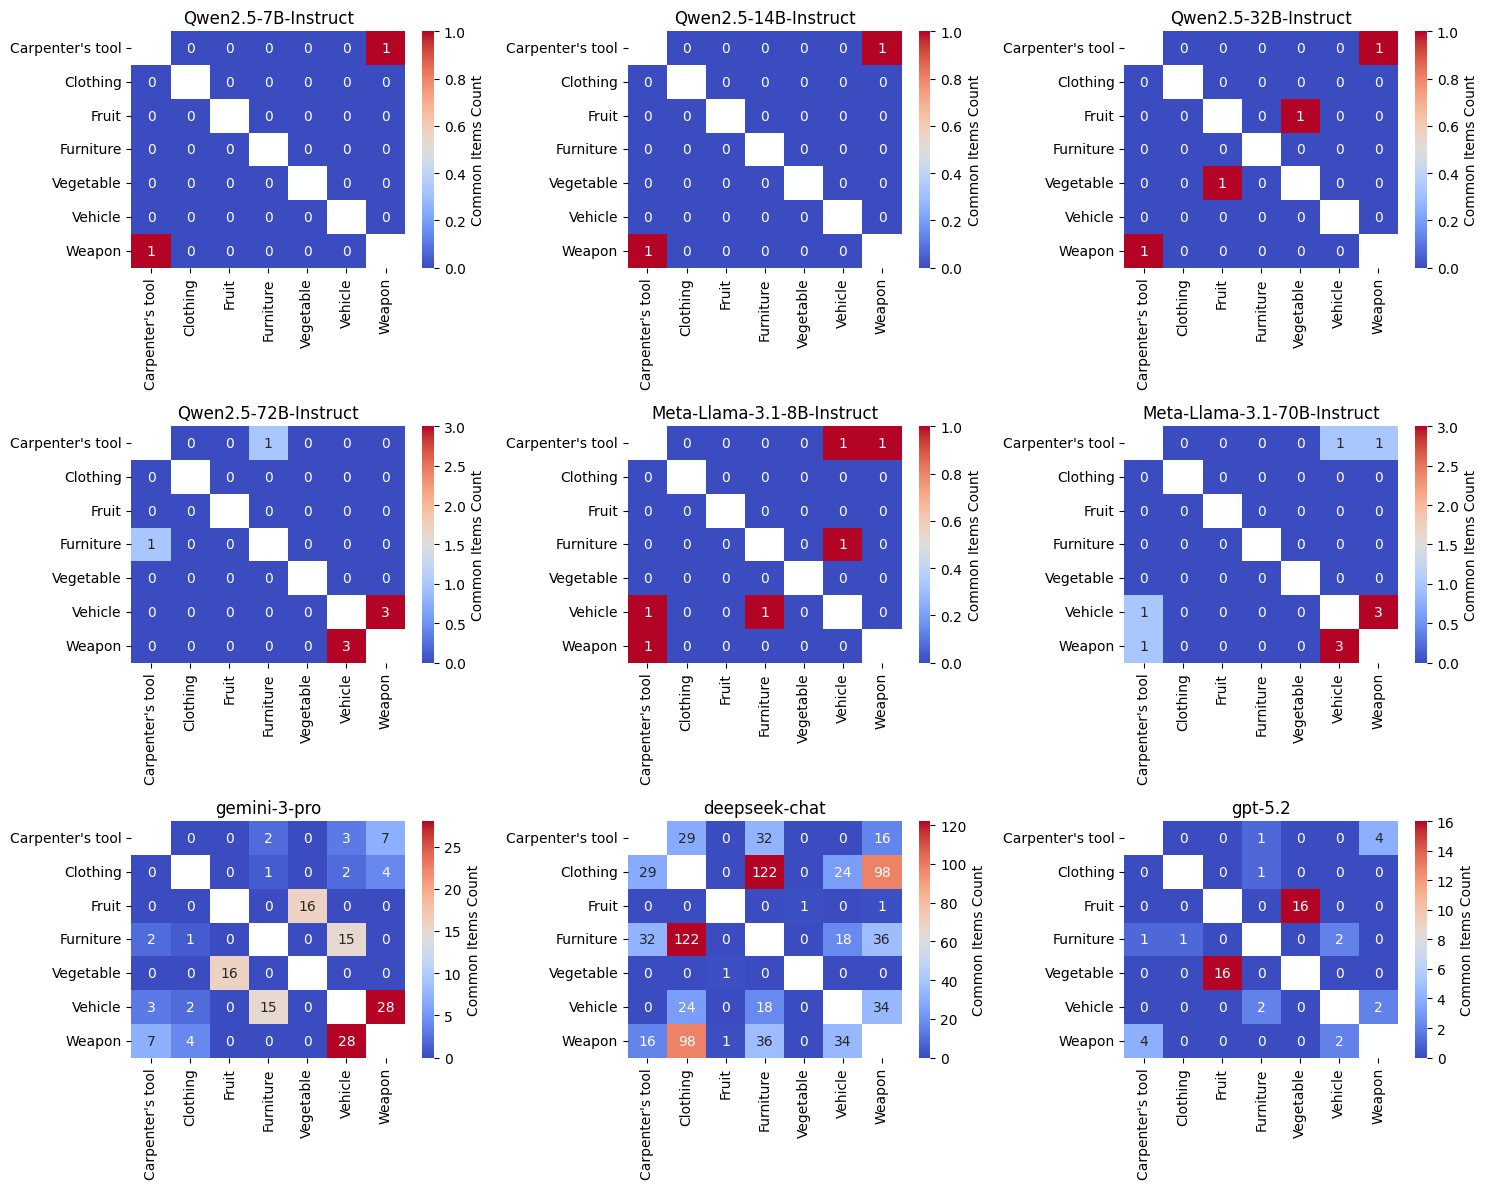

In [ ]:
model_dataframes = {}

unique_models = items_df['model'].unique()

for model in unique_models:
   
    model_df = items_df[items_df['model'] == model]

    grouped = model_df.groupby('category')['output_list_processed_nonoise'].agg(lambda x: set(sum(x, [])))

    common_counts = pd.DataFrame(index=grouped.index, columns=grouped.index)

    for cat1 in grouped.index:
        for cat2 in grouped.index:
            if cat1 != cat2:
                common_count = len(grouped[cat1].intersection(grouped[cat2]))
                common_counts.loc[cat1, cat2] = common_count
            else:
                common_counts.loc[cat1, cat2] = len(grouped[cat1])

    common_counts = common_counts.apply(pd.to_numeric, errors='coerce')

    model_dataframes[model] = common_counts

n_models = len(model_dataframes)
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))

axes = axes.flatten()

for ax, (model, counts) in zip(axes, model_dataframes.items()):
    
    mask = np.zeros_like(counts, dtype=bool)
    np.fill_diagonal(mask, True)

    sns.heatmap(counts, annot=True, cmap='coolwarm', fmt='g', ax=ax, 
                cbar_kws={'label': 'Common Items Count'}, mask=mask) 
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.tight_layout()  
plt.show()

In [ ]:
# Common Attributes between categories (tables)

unique_models = unique_attributes_df['model'].unique()

model_common_attributes_counts = {}

for model in unique_models:

    model_df = unique_attributes_df[unique_attributes_df['model'] == model]

    categories = model_df['category'].unique()

    category_attributes = {category: set() for category in categories}

    for category in categories:
        category_df = model_df[model_df['category'] == category]
        attributes = category_df['attributes'].apply(eval).explode().unique()
        category_attributes[category] = set(attributes)

    common_attributes_counts = pd.DataFrame(index=categories, columns=categories)

    for category1 in categories:
        for category2 in categories:
            if category1 != category2:
                common_count = len(category_attributes[category1].intersection(category_attributes[category2]))
                common_attributes_counts.loc[category1, category2] = common_count
            else:
                common_attributes_counts.loc[category1, category2] = len(category_attributes[category1])

    model_common_attributes_counts[model] = common_attributes_counts

for model, df in model_common_attributes_counts.items():
    print(f"\n{model}")
    print(df)



Qwen2.5-7B-Instruct
          Furniture Vehicle Vegetable Weapon Fruit Clothing
Furniture       142      16         4     15     5       26
Vehicle          16      79         4     17     5       13
Vegetable         4       4        66      4    24        6
Weapon           15      17         4    113     4       15
Fruit             5       5        24      4    60        7
Clothing         26      13         6     15     7      124

Qwen2.5-14B-Instruct
          Furniture Vehicle Vegetable Weapon Fruit Clothing
Furniture       130      29        11     18     8       39
Vehicle          29     183        16     29    14       24
Vegetable        11      16       107      8    33       13
Weapon           18      29         8    143     9       18
Fruit             8      14        33      9   101        9
Clothing         39      24        13     18     9      177

Qwen2.5-32B-Instruct
          Furniture Vehicle Vegetable Weapon Fruit Clothing
Furniture       176      28        

C:\Users\AS\AppData\Local\Temp\ipykernel_8276\2581549709.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.heatmap(df.fillna(0), annot=True, fmt="d", cmap='coolwarm',
C:\Users\AS\AppData\Local\Temp\ipykernel_8276\2581549709.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.heatmap(df.fillna(0), annot=True, fmt="d", cmap='coolwarm',
C:\Users\AS\AppData\Local\Temp\ipykernel_8276\2581549709.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objec

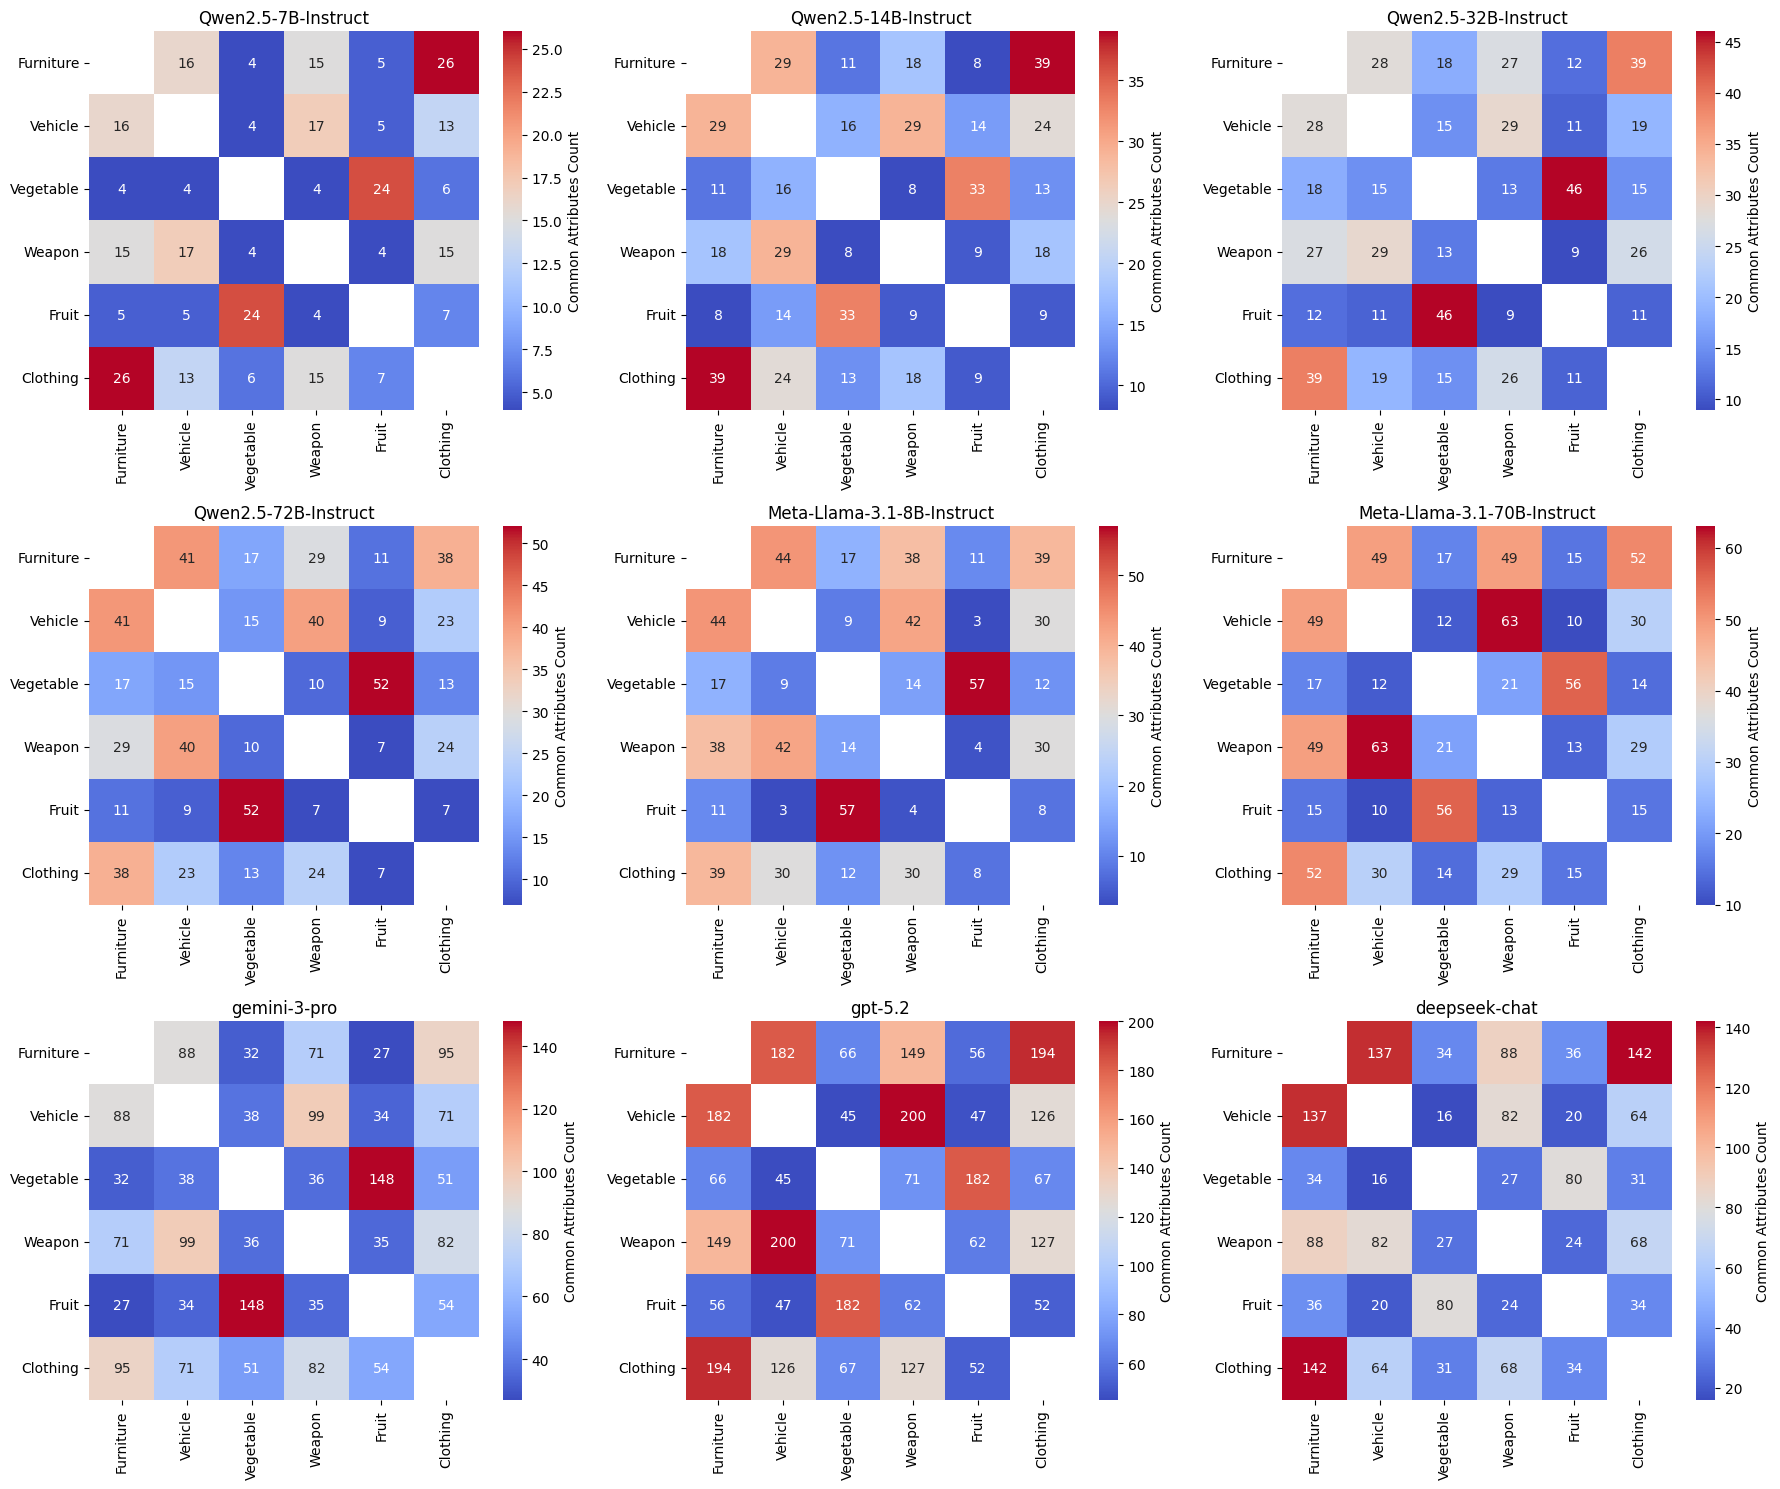

In [ ]:
unique_models = unique_attributes_df['model'].unique()

model_common_attributes_counts = {}

for model in unique_models:
    
    model_df = unique_attributes_df[unique_attributes_df['model'] == model]

    categories = model_df['category'].unique()

    category_attributes = {category: set() for category in categories}

    for category in categories:
        category_df = model_df[model_df['category'] == category]
        attributes = category_df['attributes'].apply(eval).explode().unique()
        category_attributes[category] = set(attributes)

    common_attributes_counts = pd.DataFrame(index=categories, columns=categories)

    for category1 in categories:
        for category2 in categories:
            if category1 != category2:
                common_count = len(category_attributes[category1].intersection(category_attributes[category2]))
                common_attributes_counts.loc[category1, category2] = common_count
            else:
                common_attributes_counts.loc[category1, category2] = np.nan

    model_common_attributes_counts[model] = common_attributes_counts

num_models = len(model_common_attributes_counts)
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 6, n_rows * 5))

axes = axes.flatten()

for ax, (model, df) in zip(axes, model_common_attributes_counts.items()):

    mask = np.zeros(df.shape, dtype=bool)  
    np.fill_diagonal(mask, True)  

    sns.heatmap(df.fillna(0), annot=True, fmt="d", cmap='coolwarm', 
                ax=ax, mask=mask, cbar_kws={'label': 'Common Attributes Count'})

    ax.set_title(f'{model}')
    ax.set_xlabel('')
    ax.set_ylabel('')

for i in range(len(model_common_attributes_counts), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()